# Run a VCell PDE simulation from solver input files
1. Copy all files from solver_input directory to a temporary directory for solving
2. prepare empty solver output directory, copying in the functions file
2. Execute the Finite Volume PDE solver

### In this example, we are using the Model instance as an example, as the get input files endpoint is not yet implemented.

In [1]:
from pathlib import Path

import tempfile
import shutil
import os

from pyvcell.vcml.simulation import SbmlSpatialSimulation
from pyvcell.sbml.sbml_spatial_model import SbmlSpatialModel


def get_temp_solver_dir(solver_input_dir: Path, temp_dir_prefix: str = None) -> Path:
    # prepare input dir
    temp_solver_dir = Path(tempfile.mkdtemp(prefix=temp_dir_prefix or 'pyvcell_test_data_'))
    for file in solver_input_dir.iterdir():
        shutil.copy(file, temp_solver_dir)

    return temp_solver_dir


def prepare_output_dir(solver_output_dir: Path, functions_file: Path) -> None:
    # prepare output dir: clear contents of solver_output_dir
    for file in solver_output_dir.iterdir():
        if file.is_file() and not file.name.startswith('.'):
            file.unlink()

    # copy functions file to solver_output_dir
    shutil.copy(functions_file, solver_output_dir)


# define input dir, output_dir and spatial model
solver_input_dir = Path(os.getcwd()) / "solver_input"
temp_solver_dir = get_temp_solver_dir(solver_input_dir)
functions_file = temp_solver_dir / "SimID_946368938_0_.functions"

solver_output_dir = Path(os.getcwd()) / "test_output"

model_fp = os.path.join(solver_input_dir, "TinySpatialProject_Application0.xml")

# define editable spatial model and simulation instances
model = SbmlSpatialModel(filepath=model_fp)
simulation = SbmlSpatialSimulation(sbml_model=model, out_dir=solver_output_dir)

# TODO: replace below with simulation.get_input_files()
fv_input_file = temp_solver_dir / "SimID_946368938_0_.fvinput"
vcg_file = temp_solver_dir / "SimID_946368938_0_.vcg"

In [2]:
# job_id = 0
# sim_id = 946368938

result = simulation.run()
job_id = result.job_id
sim_id = result.sim_id

initializing mesh
numVolume=200

mesh initialized
preprocessing finished
pdeCount=2, odeCount=0
error opening log file </Users/alexanderpatrie/Desktop/repos/pyvcell/examples/test_output/SimID_190714333_0_.log>
simulation [SimID_190714333_0_] started
temporary directory used is /var/folders/yy/8crj8x7x5_3b86f0js6_0bn00000gr/T/
sim file name is /var/folders/yy/8crj8x7x5_3b86f0js6_0bn00000gr/T/SimID_190714333_0_0000.sim
**This is a little endian machine.**
[[[data:0]]]
numVolRegions=1
Region 0: size=200, offset=0
# of active points = 200
Constant diffusion/advection in region subdomain00
numUnknowns = 400

****** using Sundials CVode with PREC_LEFT, relTol=1e-07, absTol=1e-09, maxStep=0.1

----------------------------------
sundials pde solver is starting from time 0
----------------------------------
temporary directory used is /var/folders/yy/8crj8x7x5_3b86f0js6_0bn00000gr/T/
sim file name is /var/folders/yy/8crj8x7x5_3b86f0js6_0bn00000gr/T/SimID_190714333_0_0001.sim
[[[data:0.1]]]tempo

Simulation Complete in Main() ... 


In [3]:
from pyvcell.data_model.vtk_data import VtkData

vtk_data: VtkData = result.vtk_data
dir(vtk_data)

subdomain0::s0 VariableType.VOLUME
subdomain0::s1 VariableType.VOLUME
vcRegionVolume VariableType.VOLUME_REGION
vcRegionArea VariableType.MEMBRANE_REGION
vcRegionVolume_subdomain0 VariableType.MEMBRANE_REGION


['__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'get_vis_mesh',
 'get_vtk_grid',
 'get_vtu_file',
 'mesh',
 'out_dir',
 'plot',
 'times',
 'vtu_files',
 'write_mesh_animation']

In [4]:
from pyvcell.data_model.plotter import Plotter

plotter: Plotter = result.plotter
dir(plotter)

['__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'animate_channel_3d',
 'animate_image',
 'channels',
 'concentrations',
 'get_3d_slice_animation',
 'get_image_animation',
 'mesh',
 'num_timepoints',
 'plot_averages',
 'plot_concentrations',
 'plot_image',
 'plot_slice_2d',
 'plot_slice_3d',
 'post_processing',
 'times',
 'zarr_dataset']

In [5]:
def get_plottable_indices():
    import numpy as np

    nchannels = result.zarr_dataset.shape[1]
    valid = []
    for n, i in enumerate(list(range(nchannels))):
        x = result.zarr_dataset[0, n, :, :, :]
        any = np.any(x)
        valid.append(i) if any else None

    return list(set(valid))

In [6]:
indices = get_plottable_indices()

indices, result.zarr_dataset.shape

([2, 5, 6, 7, 8, 9], (51, 10, 1, 1, 200))

In [9]:
ids = result.get_channel_ids()
s1 = result.get_channel('s1')
time_index = 3
data = result.get_slice(time_index, s1.label)

In [12]:
data.ndim

3

In [8]:
channels = result.zarr_dataset.attrs.asdict()["metadata"].get("channels")

In [9]:
result.zarr_dataset.shape

(51, 10, 1, 1, 200)

In [10]:
x = [1, 4, 5, 3, 6, 35]
y = list(filter(
    lambda v: v % 2 == 0,
    x
))

In [14]:


def get_channel(self, label: str):
    getter = filter(lambda c: c.label == label, self.channel_data)
    c = next(getter, None)

    if c is None:
        raise ValueError(f"No channel found with label '{label}'")

    if next(getter, None) is not None:
        raise ValueError(f"More than one '{label}' channel found")

    return c


chan = get_channel(result, 's0')
chan

ChannelMetadata(index=5, label='s0', domain_name='subdomain0', min_value=None, max_value=None, min_values=[0.0, 0.46464902525928864, 0.8645283094836882, 1.2086677413467835, 1.5048356119673365, 1.7597188998511473, 1.9790726293721292, 2.1678494351600985, 2.3303119254238944, 2.470127966880844, 2.590454410151291, 2.694007931394946, 2.783126654512909, 2.859822652607626, 2.9258276388928546, 2.982631884935937, 3.0315178958838414, 3.0735894595873883, 3.1097965069383324, 3.140956504205041, 3.167772893474702, 3.1908512206258255, 3.210712523706638, 3.2278052464365286, 3.2425153456691467, 3.2551749434363484, 3.2660698450139596, 3.2754460609589935, 3.283515272280462, 3.2904596743707386, 3.296436069055237, 3.3015793718980273, 3.306005727062094, 3.309815063098956, 3.313093396640947, 3.3159147442093833, 3.318342811684955, 3.3204324190688848, 3.3222307472028985, 3.3237783954804136, 3.325110308262511, 3.3262565611040666, 3.327243030756797, 3.3280919902688684, 3.3288226072577833, 3.329451381681153, 3.329

In [15]:
import numpy as np
channel_id = chan.label
np.array([result.get_slice(channel_id, int(t)) for t in result.get_times()])

ValueError: No channel found with label '0'

In [2]:
next(iter([1, 2, 3]))

1

In [18]:
[(channel.label, channel.min_values) for channel in result.metadata.channels]

[('s0',
  [0.0,
   0.46464902525928864,
   0.8645283094836882,
   1.2086677413467835,
   1.5048356119673365,
   1.7597188998511473,
   1.9790726293721292,
   2.1678494351600985,
   2.3303119254238944,
   2.470127966880844,
   2.590454410151291,
   2.694007931394946,
   2.783126654512909,
   2.859822652607626,
   2.9258276388928546,
   2.982631884935937,
   3.0315178958838414,
   3.0735894595873883,
   3.1097965069383324,
   3.140956504205041,
   3.167772893474702,
   3.1908512206258255,
   3.210712523706638,
   3.2278052464365286,
   3.2425153456691467,
   3.2551749434363484,
   3.2660698450139596,
   3.2754460609589935,
   3.283515272280462,
   3.2904596743707386,
   3.296436069055237,
   3.3015793718980273,
   3.306005727062094,
   3.309815063098956,
   3.313093396640947,
   3.3159147442093833,
   3.318342811684955,
   3.3204324190688848,
   3.3222307472028985,
   3.3237783954804136,
   3.325110308262511,
   3.3262565611040666,
   3.327243030756797,
   3.3280919902688684,
   3.328822

In [7]:

time_index = 0
channel_index = 2
z_index = 0

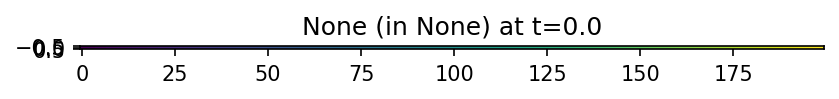

In [8]:
plotter.plot_slice_2d(time_index, channel_index, z_index)

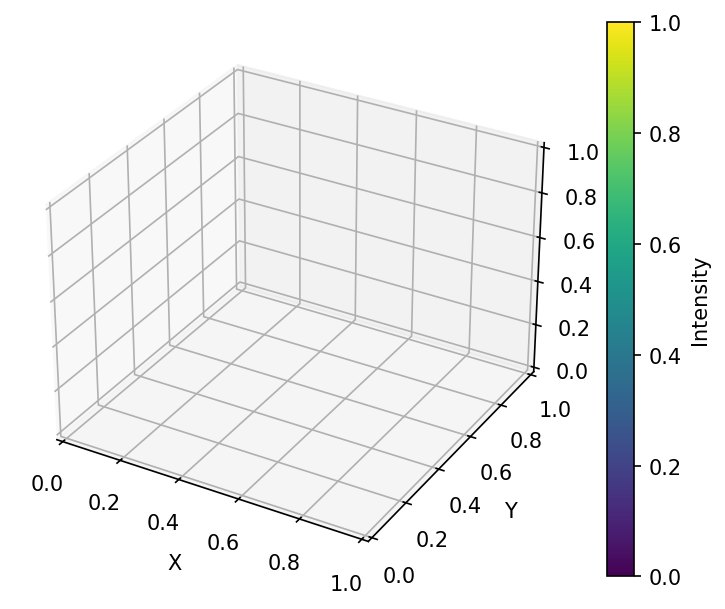

In [9]:
plotter.plot_slice_3d(time_index, channel_index)
# result.plot_slice_3d(time_index, channel_index)

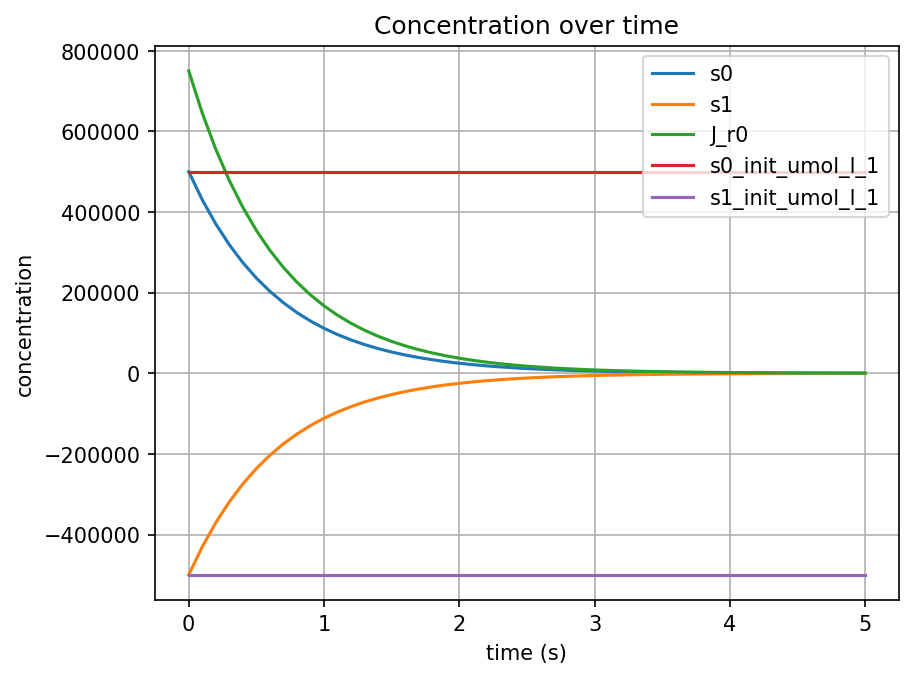

In [10]:
plotter.plot_concentrations()
# result.plot_concentrations()

|## extract the vcell simulation dataset from the tarball (compressed to save space)

## read vcell simulation results metadata
* `PdeDataSet` contains the metadata for the tabular simulation results (e.g. state variables, shape, time points)
* `DataFunctions` contains the function definitions (name, expression, type, domain)
![vcell simulation results](./example_vcell_ui.png)

## write the vcell simulation dataset to zarr including:
* metadata
* numerical datasets from stored data and evaluated functions
* ... masks for domains coming soon (e.g. cell, extracellular, etc.)

## Open and display slices from the zarr dataset as an image
* no masking for domains
* different colormap and scaling

## Open and display slices from the post processing dataset as an image

In [11]:
len(result.channels)

5

Any mask: False
got shapes: (0,), (0,), (0,)
Any mask: False
got shapes: (0,), (0,), (0,)
Any mask: False
got shapes: (0,), (0,), (0,)
Any mask: False
got shapes: (0,), (0,), (0,)
Any mask: False
got shapes: (0,), (0,), (0,)
Any mask: False
got shapes: (0,), (0,), (0,)
Any mask: False
got shapes: (0,), (0,), (0,)
Any mask: False
got shapes: (0,), (0,), (0,)
Any mask: False
got shapes: (0,), (0,), (0,)
Any mask: False
got shapes: (0,), (0,), (0,)
Any mask: False
got shapes: (0,), (0,), (0,)
Any mask: False
got shapes: (0,), (0,), (0,)
Any mask: False
got shapes: (0,), (0,), (0,)
Any mask: False
got shapes: (0,), (0,), (0,)
Any mask: False
got shapes: (0,), (0,), (0,)
Any mask: False
got shapes: (0,), (0,), (0,)
Any mask: False
got shapes: (0,), (0,), (0,)
Any mask: False
got shapes: (0,), (0,), (0,)
Any mask: False
got shapes: (0,), (0,), (0,)
Any mask: False
got shapes: (0,), (0,), (0,)
Any mask: False
got shapes: (0,), (0,), (0,)
Any mask: False
got shapes: (0,), (0,), (0,)
Any mask: 

Any mask: False
got shapes: (0,), (0,), (0,)


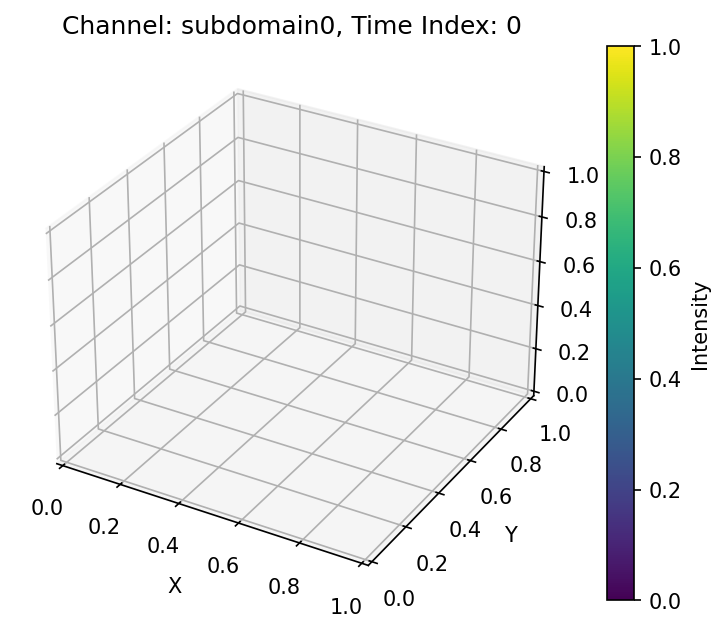

In [12]:


result.plotter.animate_channel_3d(channel_index)

In [20]:
result.channels

[Channel(index=5, label='s0', domain_name='subdomain0', mean_values=[500000.00000000006, 430354.49464251864, 370410.0709214147, 318815.24570086243, 274407.2182241792, 236184.9250611906, 203286.71678956892, 174970.99041954466, 150599.39073224773, 129622.5637979974, 111567.6365951872, 96027.62248550024, 82652.20414429814, 71139.87995600591, 61231.12825225584, 52702.58413918237, 45362.00022444572, 39043.89909552203, 33605.8522337663, 28925.277645120146, 24896.679062681855, 21429.231064709908, 18444.77414050456, 15876.030433996015, 13665.089787985999, 11762.113620339813, 10124.208564831202, 8714.449205774627, 7501.059079758395, 6456.6846893262145, 5557.782130200425, 4784.091306801051, 4118.168925329845, 3545.0052573723037, 3051.678668593173, 2627.0688788549764, 2261.6035415134174, 1947.0445010734547, 1676.3007402543858, 1443.2696654784238, 1242.6980776316473, 1070.06416644645, 921.4769374043233, 793.5868721603339, 683.511115191187, 588.7677375544962, 507.2212074380988, 437.0336540243645, 3

In [19]:
nchannels = result.zarr_dataset.shape[1]
len(result.channels)

5

In [13]:
result.metadata.mesh

MeshMetadata(size=[200, 1, 1], extent=[10.0, 1.0, 1.0], origin=[0.0, 0.0, 0.0], volume_regions=[MeshVolumeRegion(region_index=0, domain_type_index=0, volume=10.000000000000034, domain_name='subdomain0')])

@

In [26]:
valid

[2, 5, 6, 7, 8, 9]

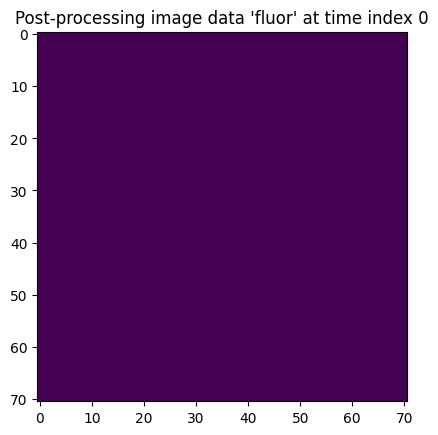

In [8]:
# animate fluor dataset image over time
fluor_index = 0
result.plotter.animate_image(fluor_index)

## Open and display Variable Statistics from the post processing dataset

In [5]:
post_processing = result.post_processing
post_processing.variables[0].stat_var_unit

'uM'

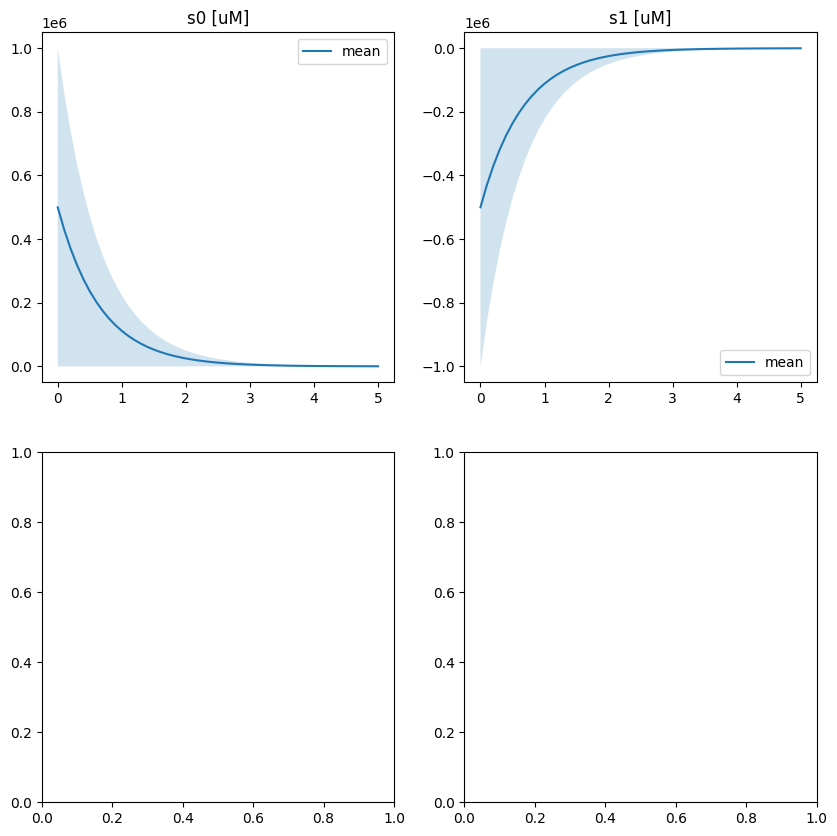

In [6]:
plotter.plot_averages()

In [14]:
import numpy as np


x = np.random.random_sample(51, 10, 1, 1, 200)

TypeError: random_sample() takes at most 1 positional argument (5 given)

In [13]:
x

array([], dtype=int64)